# 사례 연구

## Bike Sharing Demand

- 도시 자전거 공유 시스템 사용 예측
- [캐글](https://www.kaggle.com)의 [Bike Sharing Demand](https://www.kaggle.com/c/bike-sharing-demand)에서 `train.csv`를 다운로드
- 파일을 data 디렉토리에 `bike_train.csv`로 저장

**datetime** : hourly date + timestamp  
**season** : 1 = 봄, 2 = 여름, 3 = 가을, 4 = 겨울  
**holiday**: 1 = 토, 일요일의 주말을 제외한 국경일 등의 휴일, 0 = 휴일이 아닌 날  
**workingday**: 1 = 토, 일요일의 주말 및 휴일이 아닌 주중, 0 = 주말 및 휴일  
**weather**:  
- 1 = 맑음, 약간 구름 낀 흐림  
- 2 = 안개, 안개 + 흐림  
- 3 = 가벼운 눈, 가벼운 비 + 천둥  
- 4 = 심한 눈/비, 천둥/번개  

**temp**: 온도(섭씨)   
**atemp**: 체감온도(섭씨)  
**humidity**: 상대습도  
**windspeed**: 풍속  
**casual**: 사전에 등록되지 않는 사용자가 대여한 횟수  
**registered**: 사전에 등록된 사용자가 대여한 횟수  
**count**: 대여 횟수  

## Step 1: 질문하기 (Ask questions)
데이터가 주어진 상태에서 질문을 할 수도 있고, 질문에 답할 수 있는 데이터를 수집할 수도 있다.

**질문 예시**
- 질문 1. 어떤 기후 특성이 자전거 대여량에 영향을 미칠까?
- 질문 2. 어떤 시간대(요일, 달, 계절..)에 대여량이 많을까?


## Step 2: 데이터 랭글링 (Wrangle data)
- 데이터 랭글링 : 원자료(raw data)를 보다 쉽게 접근하고 분석할 수 있도록 데이터를 정리하고 통합하는 과정
(참고. 위키피디아)
- 세부적으로는 데이터의 수집(gather), 평가(assess), 정제(clean) 작업으로 나눌 수 있다.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**데이터 수집(gather)**

In [ ]:
bike = pd.read_csv('./data/bike_train.csv')

**평가(assess)**

In [ ]:
bike.shape

(10886, 12)

In [ ]:
bike.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


**정제(clean)**

- 누락데이터는 없으나, datetime 의 타입이 문자열로 되어 있음
- 효과적인 분석을 위해 datetime 특성을 datetime(pandas에서 제공하는 타입)으로 바꾼 뒤
- 년, 월, 요일, 시간 등을 추출

In [ ]:
bike['datetime'] = pd.to_datetime(bike['datetime'])

In [ ]:
a = bike.iloc[0, 0]
a

Timestamp('2011-01-01 00:00:00')

In [ ]:
a.year

2011

In [ ]:
bike.info()

In [ ]:
def get_year(x):
    return x.year

get_year(a)

2011

In [ ]:
bike['datetime']

,datetime
0,2011-01-01 00:00:00
1,2011-01-01 01:00:00
2,2011-01-01 02:00:00
3,2011-01-01 03:00:00
4,2011-01-01 04:00:00
...,...
10881,2012-12-19 19:00:00
10882,2012-12-19 20:00:00
10883,2012-12-19 21:00:00
10884,2012-12-19 22:00:00


In [ ]:
bike['datetime'].apply(get_year) # 시리즈 데이터 10886건에 대해서 일괄 함수를 적용

,datetime
0,2011
1,2011
2,2011
3,2011
4,2011
...,...
10881,2012
10882,2012
10883,2012
10884,2012


In [ ]:
bike['year'] = bike['datetime'].apply(lambda x: x.year)
bike['month'] = bike['datetime'].apply(lambda x: x.month)
bike['hour'] = bike['datetime'].apply(lambda x: x.hour)
bike['dayofweek'] = bike['datetime'].apply(lambda x: x.dayofweek)

In [ ]:
bike.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,hour,dayofweek
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,0,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,2,5
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,3,5
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,4,5


- season과 weather 컬럼을 숫자에서 실제 의미 있는 단어로 표시
- **season** (1 = 봄,  2 = 여름, 3 = 가을, 4 = 겨울  )
- **weather** (1 = 맑음, 약간 구름 낀 흐림, 2 = 안개, 안개 + 흐림, 3 = 가벼운 눈, 가벼운 비 + 천둥, 4 = 심한 눈/비, 천둥/번개)

In [ ]:
bike['season'] = bike['season'].map({1 : 'Spring',
                                     2 : 'Summer',
                                     3 : 'Fall',
                                     4 : 'Winter'})

bike['weather'] = bike['weather'].map({1 : 'Clear',
                                       2 : 'Mist, Few clouds',
                                       3 : 'Light Snow, Rain, Thunder',
                                       4 : 'Heavy Snow, Rain, Thunder'})

## Step 3: 데이터 탐색 (Exploratory Data Analysis)
데이터의 패턴을 찾고, 관계를 시각화 하는 작업을 통해 데이터에 대한 직관을 극대화 한다.

In [ ]:
bike.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'year', 'month', 'hour', 'dayofweek'],
      dtype='object')

In [ ]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  object        
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  object        
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int64         
 13  month       10886 non-null  int64         
 14  hour        10886 non-null  int64         
 15  dayofweek   10886 non-null  int64         
dtypes: datetime64[ns](1), 

In [ ]:
numeric_columns = ['temp', 'atemp', 'humidity', 'windspeed', 'count']
categorical_columns = ['season', 'weather', 'holiday', 'year', 'month', 'dayofweek', 'hour' ]

### 수치형 데이터

In [ ]:
bike[numeric_columns]

,temp,atemp,humidity,windspeed,count
0,9.84,14.395,81,0.0000,16
1,9.02,13.635,80,0.0000,40
2,9.02,13.635,80,0.0000,32
3,9.84,14.395,75,0.0000,13
4,9.84,14.395,75,0.0000,1
...,...,...,...,...,...
10881,15.58,19.695,50,26.0027,336
10882,14.76,17.425,57,15.0013,241
10883,13.94,15.910,61,15.0013,168
10884,13.94,17.425,61,6.0032,129


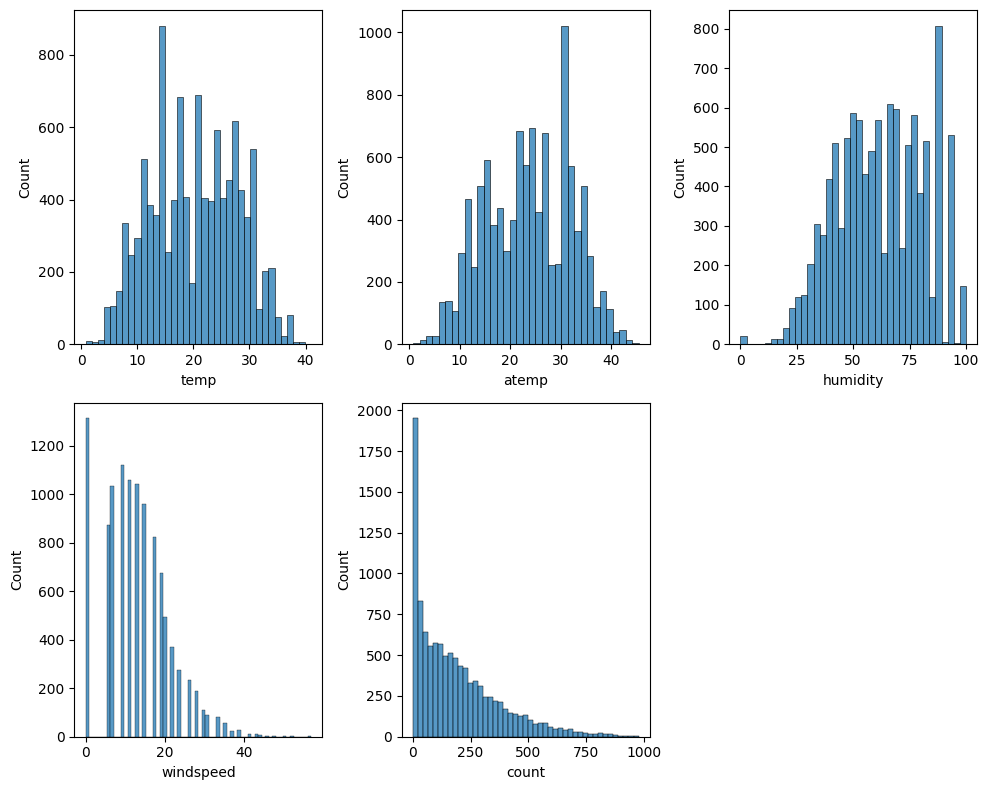

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 8))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.histplot(data=bike, x=column, ax=axes[i])

plt.delaxes(axes[-1])
plt.tight_layout()
plt.show()

- x축은 타깃값 count, y축은 빈도수(횟수)
- 오른쪽으로 꼬리가 긴 분포(windspeed, count)
- windspeed에 0값이 많음(결측치)

**Note.**
- 회귀 모델이 좋은 성능 내려면 데이터가 정규분포를 따르는게 좋음
- 데이터를 정규분포에 가깝게 만들기 위해 로그 변환 사용

### 범주형 데이터

**barplot**

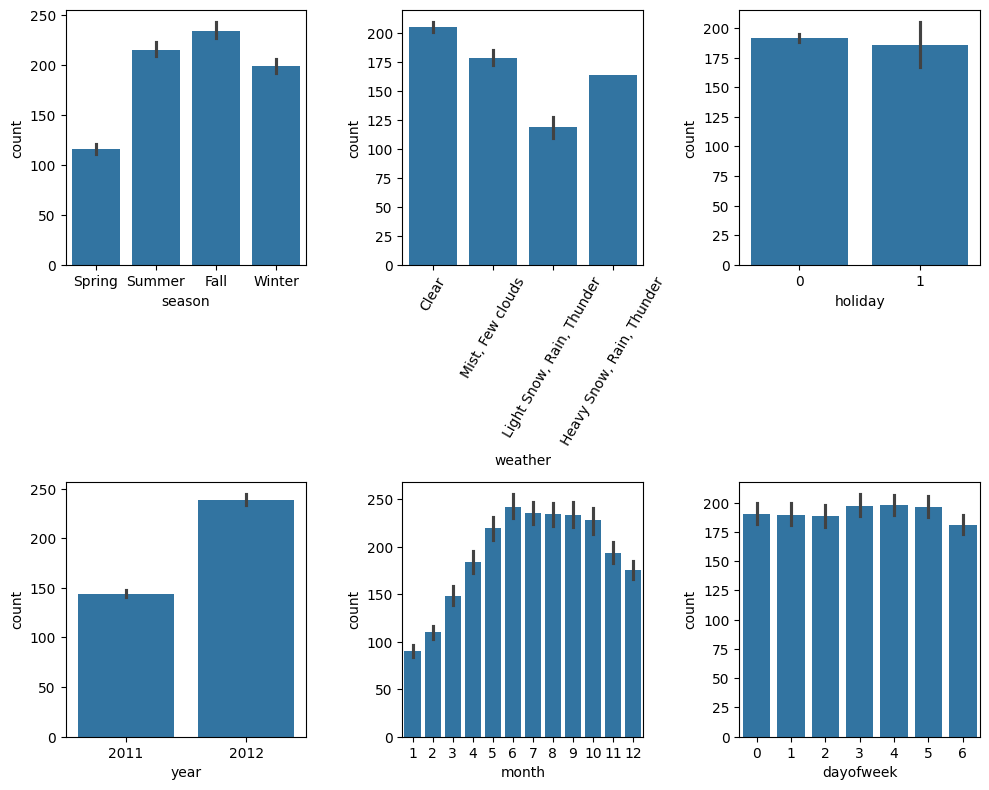

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 8))
axes = axes.flatten()

for i, column in enumerate(categorical_columns[:-1]):
    sns.barplot(data=bike, x=column, y='count', ax=axes[i])
    if i == 1:
        axes[1].tick_params(axis='x', labelrotation=60)

plt.tight_layout()
plt.show()

- 가을(Fall, 3)에 대여량이 많음 (month와 유사한 추이)
- 날씨가 좋을수록 대여 수량이 많음
- 그러나 heavy snow 기상상태에서 160건 가량의 대여량(count)이 있는것이 이상

- 년도별 대여량은 2011년보다 2012년이 더 많음
- 월별 대여량은 6월에 가장 많고, 7~10월도 대여량이 많음. 1월이 가장 적음

**pointplot**

**시간대별 자건거 대여율**
- 정보를 나눠서 보기(평일/주말)

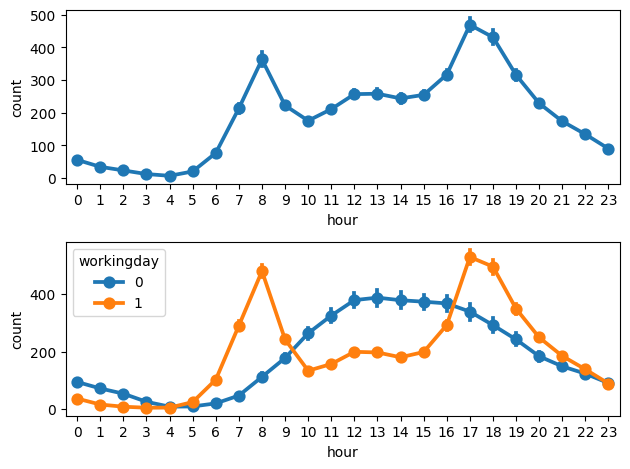

In [ ]:
figure, (ax1, ax2) = plt.subplots(nrows=2)
sns.pointplot(data=bike, x="hour", y="count", ax=ax1) # 시간별 자전거 대여량의 평균
sns.pointplot(data=bike, x="hour", y="count", hue='workingday', ax=ax2) # workingday 정보 나눠서 보기

plt.tight_layout()
plt.show()

- 시간대 대여량은 오전 8시, 오후 17~18시에 에 많은것으로 보아 출퇴근 시간대로 추측(평일/주말을 나눠서 보기)

* 근무일에는 출퇴근 시간에 대여량이 많고
* 쉬는날에는 오후 12~2시 사이에 대여량이 많음

**boxplot**

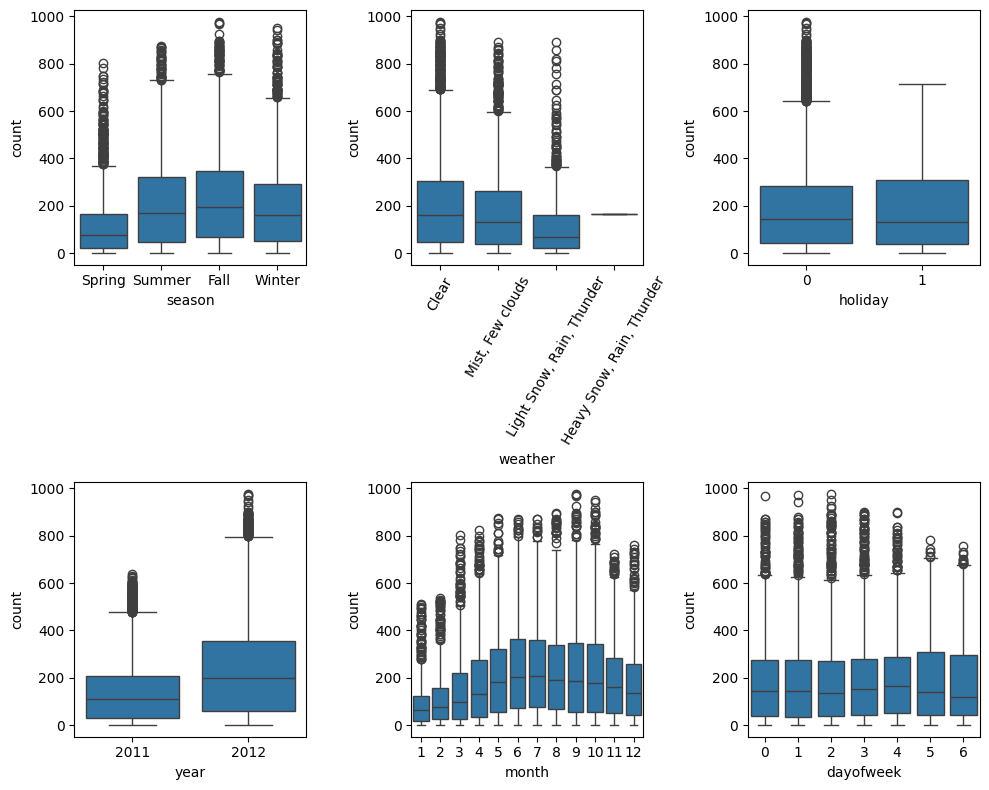

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 8))
axes = axes.flatten()

for i, column in enumerate(categorical_columns[:-1]):
    sns.boxplot(data=bike, x=column, y='count', ax=axes[i])
    if i == 1:
        axes[1].tick_params(axis='x', labelrotation=60)

plt.tight_layout()
plt.show()

- 평일(근무일)일 때 특잇값이 많음
- 악천후 속 자전거 대여수 한건에 대해 제거 고려

### 데이터 관계

**수치 데이터의 특성(변량, 속성, 컬럼)간의 관계를 확인할 떼**
- 산점도
- 상관계수

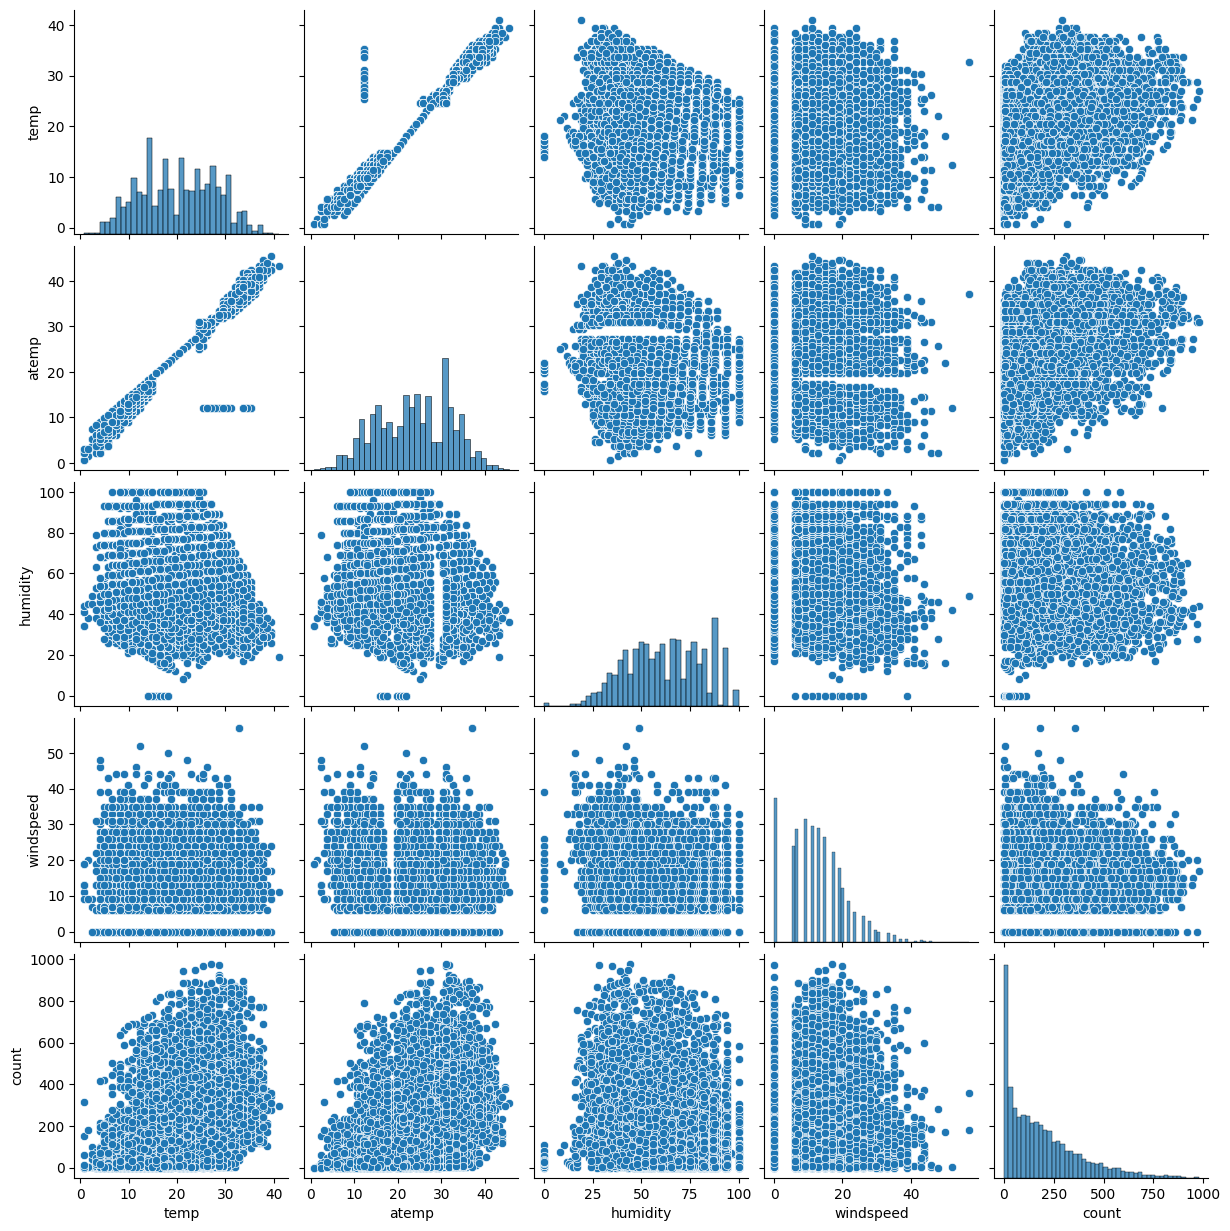

In [ ]:
sns.pairplot(data=bike[numeric_columns])
plt.show()

In [ ]:
corr_matrix = bike[numeric_columns].corr()

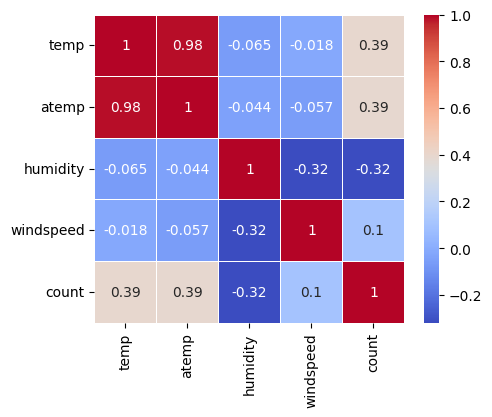

In [ ]:
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidth=0.5)
plt.show()

- 온도와 체감온도가 대여량에 영향을 미칠것으로 보임 (약한 양의 상관관계)
- 습도도 대여량에 영향을 미칠 것으로 보임(약한 음의 상관관계)

## Step 4: 결론 도출 또는 예측 (Draw conclusions or make predictions)
- Step 3에서 분석한 내용을 근거로 질문에 대한 답과 결론을 도출 할 수 있다.
- 머신러닝 또는 통계 추정 과정을 거치게 되면 예측을 만들어 낼 수도 있다.

**질문 1. 어떤 기후 특성이 자전거 대여량에 영향을 미칠까?**

**분석 결과** :
- 날씨가 좋을수록(Clear) 대여 수량이 많음
- 온도와 체감온도가 대여량에 영향을 미칠것으로 보임 (약한 양의 상관관계)
- 습도도 대여량에 영향을 미칠 것으로 보임(약한 음의 상관관계)


**질문 2. 어떤 시간대(요일, 달, 계절..)에 대여량이 많을까?**

**분석 결과**
- 연도별 평균 대여량이 2011년도보다 2012년도에 더 많음
- 월별 평균 대여량은 6월에 가장 많았고 7~10월에도 많음. 1월에 가장 적음
- 시간대별 평균 대여량은 8시 전후와 오후 17~18시 부근에 많음
    - 근무일에는 출퇴근 시간에 대여량이 많고
    - 쉬는날에는 오후 12~2시 사이에 대여량이 많음

## Step 5: 결과 공유 (Communicate the results)
보고서, 이메일, 블로그 등 다양한 방법을 통해 발견한 통찰들을 공유할 수 있다.